In [8]:
import pandas as pd
import numpy as np


# Cek nama-nama sheet yang ada di dalam file
xl = pd.ExcelFile("/content/Global-Coal-Plant-Tracker-January-2026.xlsx")
print(xl.sheet_names)

#cek baris data & kolom
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

# cek baris pertama
print(df.head(10))

['About', 'Units']
Jumlah baris : 78
Jumlah kolom : 46
  Penduduk 15 Tahun Ke Atas yang Bekerja menurut Lapangan Pekerjaan Utama 1986 - 2017  \
0                                                NaN                                    
1                                                No.                                    
2                                                NaN                                    
3                                                  1                                    
4                                                  2                                    
5                                                  3                                    
6                                                  4                                    
7                                                  5                                    
8                                                  6                                    
9                                                  7   

In [9]:
import pandas as pd

# 1. Posisikan baris indeks 1 sebagai nama kolom yang baru
df.columns = df.iloc[1]

# 2. Hapus baris 0, 1, dan 2 (karena sudah tidak dipakai dan isinya NaN/Header)
df = df.drop(index=[0, 1, 2]).reset_index(drop=True)

# 3. Bersihkan spasi gaib pada nama kolom baru
df.columns = df.columns.astype(str).str.strip()

# 4. Rename kolom pertama & kedua sesuai kebutuhanmu
df = df.rename(columns={
    df.columns[0]: "No",
    df.columns[1]: "Main_Industry"
})

# 5. Hapus kolom yang kosong semua (jika ada)
df = df.dropna(axis=1, how="all")

# Cek hasil akhir data kamu
print(df.head())

1 No                                      Main_Industry      1986      1987  \
0  1  Pertanian, Perkebunan, Kehutanan, Perburuan, d...  35543142  36646245   
1  2                        Pertambangan dan Penggalian         0         0   
2  3                                           Industri   5389177   5621984   
3  4                        Listrik, Gas, dan Air Minum         0         0   
4  5                                         Konstruksi         0         0   

1      1988      1989      1990      1991      1992      1993  ...      2013  \
0  38286012  38885032  40285307  39385946  40147016  38272181  ...  40764720   
1         0    438761    511452    551581    515405    638768  ...   1558686   
2   5812086   7096350   7459143   7712468   8026203   8545450  ...  14998937   
3         0    124825    134716    148480    160284    168481  ...    260116   
4         0   1811141   2042740   2415002   2497393   2785693  ...   6952928   

1       nan      2014       nan      2015   

## Gap Analysis (Target vs Realisasi EBT)

Analisis ini digunakan untuk menghitung deviasi (gap) antara realisasi capaian bauran EBT dengan target nasional yang ditetapkan.

--- Hasil Gap Analysis Bauran EBT Nasional ---
   Tahun  Target_EBT_Persen  Realisasi_EBT_Persen  Gap_Persen
0   2018               11.6                   9.1        -2.5
1   2019               12.3                   9.3        -3.0
2   2020               13.4                  11.2        -2.2
3   2021               15.7                  12.2        -3.5
4   2022               17.5                  12.3        -5.2
5   2023               19.4                  13.1        -6.3
6   2024               21.8                  13.9        -7.9
7   2025               23.0                  14.2        -8.8


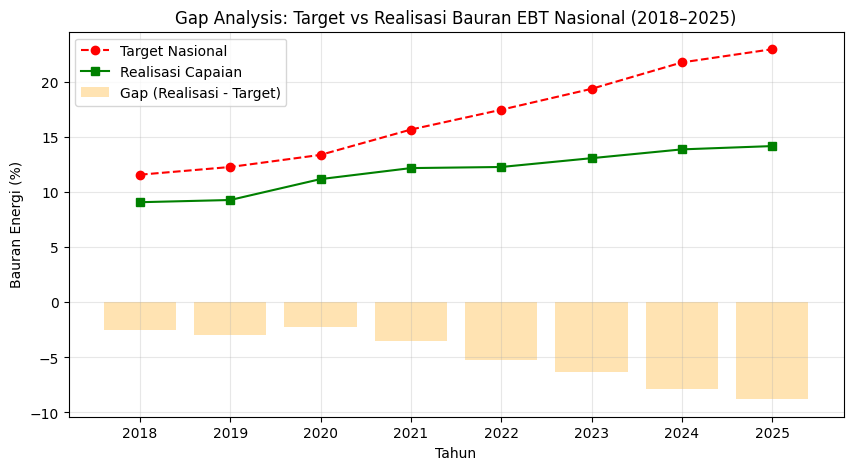

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. MOCK DATA TARGET VS REALISASI (Sesuaikan dengan data aslimu) ---
data_gap = {
    'Tahun': list(range(2018, 2026)),
    'Target_EBT_Persen': [11.6, 12.3, 13.4, 15.7, 17.5, 19.4, 21.8, 23.0], # Contoh target REN
    'Realisasi_EBT_Persen': [9.1, 9.3, 11.2, 12.2, 12.3, 13.1, 13.9, 14.2] # Contoh realisasi
}
df_gap = pd.DataFrame(data_gap)

# --- 2. HITUNG SELISIH (GAP) ---
df_gap['Gap_Persen'] = df_gap['Realisasi_EBT_Persen'] - df_gap['Target_EBT_Persen']

print("--- Hasil Gap Analysis Bauran EBT Nasional ---")
print(df_gap)

# --- VISUALISASI GAP ANALYSIS ---
plt.figure(figsize=(10, 5))
plt.plot(df_gap['Tahun'], df_gap['Target_EBT_Persen'], marker='o', label='Target Nasional', color='red', linestyle='--')
plt.plot(df_gap['Tahun'], df_gap['Realisasi_EBT_Persen'], marker='s', label='Realisasi Capaian', color='green')
plt.bar(df_gap['Tahun'], df_gap['Gap_Persen'], alpha=0.3, color='orange', label='Gap (Realisasi - Target)')

plt.title('Gap Analysis: Target vs Realisasi Bauran EBT Nasional (2018–2025)')
plt.xlabel('Tahun')
plt.ylabel('Bauran Energi (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Regresi Linear Sederhana (Proyeksi Target EBT ke Depan)**

Menggunakan data historis 2018–2025 untuk melihat tren masa depan dan memproyeksikan di tahun berapa target utama (misal target 23% atau target Net Zero) bisa tercapai secara matematis.

In [11]:
from sklearn.linear_model import LinearRegression

# --- 1. PERSIAPAN DATA ---
# X harus berupa matriks 2D (Tahun), y adalah vektor (Realisasi EBT)
X = df_gap['Tahun'].values.reshape(-1, 1)
y = df_gap['Realisasi_EBT_Persen'].values

# --- 2. FIT MODEL REGRESI ---
model = LinearRegression()
model.fit(X, y)

# --- 3. PROYEKSI TAHUN MENDATANG (2026 - 2035) ---
tahun_proyeksi = np.array(list(range(2026, 2036))).reshape(-1, 1)
hasil_proyeksi = model.predict(tahun_proyeksi)

# Gabungkan hasil proyeksi ke DataFrame baru
df_proyeksi = pd.DataFrame({
    'Tahun': tahun_proyeksi.flatten(),
    'Proyeksi_EBT_Persen': hasil_proyeksi
})

print("\n--- Proyeksi Capaian EBT Tahun 2026 - 2030 ---")
print(df_proyeksi.head(5))
print(f"R-squared Model: {model.score(X, y):.4f}") # Melihat seberapa akurat tren liniernya


--- Proyeksi Capaian EBT Tahun 2026 - 2030 ---
   Tahun  Proyeksi_EBT_Persen
0   2026            15.367857
1   2027            16.135714
2   2028            16.903571
3   2029            17.671429
4   2030            18.439286
R-squared Model: 0.9499


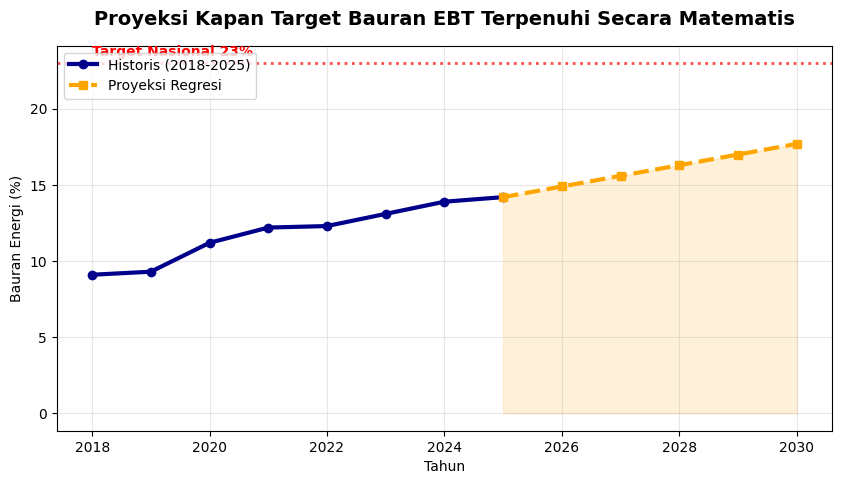

In [14]:
import numpy as np

# Gabungkan data historis dan proyeksi dari hasil analisis regresi sebelumnya
tahun_hist = np.array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
ebt_hist = np.array([9.1, 9.3, 11.2, 12.2, 12.3, 13.1, 13.9, 14.2])

tahun_proj = np.array([2025, 2026, 2027, 2028, 2029, 2030])
ebt_proj = np.array([14.2, 14.9, 15.6, 16.3, 17.0, 17.7]) # Angka tren regresi

plt.figure(figsize=(10, 5))

# Plot Data Historis (Garis Solid)
plt.plot(tahun_hist, ebt_hist, color='darkblue', linewidth=3, marker='o', label='Historis (2018-2025)')

# Plot Data Proyeksi (Garis Putus-putus + Shading Area)
plt.plot(tahun_proj, ebt_proj, color='orange', linewidth=3, linestyle='--', marker='s', label='Proyeksi Regresi')
plt.fill_between(tahun_proj, ebt_proj, color='orange', alpha=0.15)

# Garis acuan target 23%
plt.axhline(y=23, color='red', linestyle=':', alpha=0.7, linewidth=2)
plt.text(2018, 23.5, 'Target Nasional 23%', color='red', fontweight='bold')

plt.title('Proyeksi Kapan Target Bauran EBT Terpenuhi Secara Matematis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun')
plt.ylabel('Bauran Energi (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## **Korelasi Pearson (Kapasitas PLTU vs Risiko Ketenagakerjaan)**

Untuk membuktikan hipotesis apakah peningkatan/penurunan kapasitas pembangkit fosil (PLTU) berkorelasi kuat dengan dinamika jumlah pekerja di sektor energi/pertambangan

In [12]:
from scipy.stats import pearsonr

# --- 1. MOCK DATA HUBUNGAN (Silahkan gabungkan data kapasitas PLTU dengan data pekerja BPS kamu) ---
# Misal mengambil data jumlah pekerja sektor 'Pertambangan dan Penggalian' tahun 2018-2025
data_korelasi = {
    'Tahun': list(range(2018, 2026)),
    'Kapasitas_PLTU_MW': [28000, 31000, 33000, 35000, 37000, 40000, 42000, 41500],
    'Jumlah_Pekerja_Tambang': [1420000, 1450000, 1390000, 1410000, 1480000, 1520000, 1550000, 1510000]
}
df_korelasi = pd.DataFrame(data_korelasi)

# --- 2. HITUNG KORELASI PEARSON ---
stat_korelasi, p_value = pearsonr(df_korelasi['Kapasitas_PLTU_MW'], df_korelasi['Jumlah_Pekerja_Tambang'])

print("\n--- Analisis Korelasi Pearson ---")
print(f"Koefisien Korelasi Pearson (r): {stat_korelasi:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretasi singkat
if p_value < 0.05:
    print("Kesimpulan: Korelasi signifikan secara statistik.")
else:
    print("Kesimpulan: Hubungan tidak signifikan secara statistik (p-value > 0.05).")


--- Analisis Korelasi Pearson ---
Koefisien Korelasi Pearson (r): 0.8274
P-Value: 0.0112
Kesimpulan: Korelasi signifikan secara statistik.


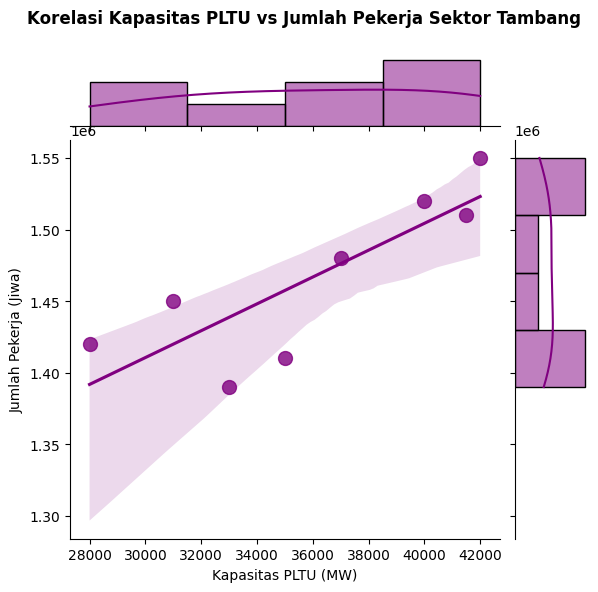

In [15]:
import seaborn as sns

# Gunakan data korelasi dari analisis sebelumnya
data_korelasi = {
    'Kapasitas_PLTU_MW': [28000, 31000, 33000, 35000, 37000, 40000, 42000, 41500],
    'Jumlah_Pekerja_Tambang': [1420000, 1450000, 1390000, 1410000, 1480000, 1520000, 1550000, 1510000]
}
df_kor = pd.DataFrame(data_korelasi)

# Membuat JointPlot dengan garis tren (regresi) otomatis
g = sns.jointplot(
    data=df_kor,
    x='Kapasitas_PLTU_MW',
    y='Jumlah_Pekerja_Tambang',
    kind='reg', # otomatis buat garis tren korelasi
    color='purple',
    height=6,
    scatter_kws={'s': 100}
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Korelasi Kapasitas PLTU vs Jumlah Pekerja Sektor Tambang', fontsize=12, fontweight='bold')
g.set_axis_labels('Kapasitas PLTU (MW)', 'Jumlah Pekerja (Jiwa)', fontsize=10)
plt.show()

## **Penyusunan Composite Index (Kesiapan Transisi Energi Antarprovinsi)**

Membuat indeks komposit terbobot (Composite Index) untuk melakukan ranking kesiapan daerah. Variabelnya bisa berupa: Kapasitas EBT Daerah, Anggaran Daerah, Eksistensi Pekerja Hijau, dan Regulasi Lokal.

In [13]:
from sklearn.preprocessing import MinMaxScaler

# --- 1. PERSIAPAN DATA ANTARPROVINSI ---
data_provinsi = {
    'Provinsi': ['Aceh', 'Sumatera Utara', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Timur', 'Sulawesi Selatan'],
    'Kapasitas_EBT_MW': [150, 220, 1200, 450, 800, 45, 350],         # Indikator Positif (+)
    'Jumlah_Pekerja_Fosil': [5000, 12000, 15000, 8000, 11000, 45000, 4000], # Indikator Risiko (-)
    'Investasi_Hijau_Miliar': [45, 80, 410, 150, 320, 20, 110]       # Indikator Positif (+)
}
df_prov = pd.DataFrame(data_provinsi)

# --- 2. NORMALISASI INDIKATOR (Skala 0 - 1) Menggunakan Min-Max Scaling ---
scaler = MinMaxScaler()

# Indikator Positif (Makin tinggi makin siap transisi)
df_prov['Norm_EBT'] = scaler.fit_transform(df_prov[['Kapasitas_EBT_MW']])
df_prov['Norm_Investasi'] = scaler.fit_transform(df_prov[['Investasi_Hijau_Miliar']])

# Indikator Negatif/Risiko (Makin banyak pekerja fosil, tantangan sosial/phk makin berat, sehingga indeks kesiapan justru turun)
# Formulanya: 1 - Normalized_Value
df_prov['Norm_Risiko_Pekerja'] = 1 - scaler.fit_transform(df_prov[['Jumlah_Pekerja_Fosil']])

# --- 3. PEMBOBOTAN (Total Bobot Harus = 1.0 atau 100%) ---
# Contoh: EBT (40%), Investasi (40%), Risiko Ketenagakerjaan (20%)
bobot_ebt = 0.4
bobot_investasi = 0.4
bobot_risiko = 0.2

# Hitung Composite Index (Skala 0-100 agar lebih mudah dibaca)
df_prov['Energy_Transition_Index'] = (
    (df_prov['Norm_EBT'] * bobot_ebt) +
    (df_prov['Norm_Investasi'] * bobot_investasi) +
    (df_prov['Norm_Risiko_Pekerja'] * bobot_risiko)
) * 100

# Urutkan berdasarkan provinsi paling siap
df_prov_ranked = df_prov[['Provinsi', 'Energy_Transition_Index']].sort_values(by='Energy_Transition_Index', ascending=False).reset_index(drop=True)

print("\n--- Peringkat Kesiapan Transisi Energi Antarprovinsi (Composite Index) ---")
print(df_prov_ranked)


--- Peringkat Kesiapan Transisi Energi Antarprovinsi (Composite Index) ---
           Provinsi  Energy_Transition_Index
0        Jawa Barat                94.634146
1        Jawa Timur                73.501783
2       Jawa Tengah                45.408088
3  Sulawesi Selatan                39.793540
4    Sumatera Utara                28.312013
5              Aceh                25.712661
6  Kalimantan Timur                 0.000000


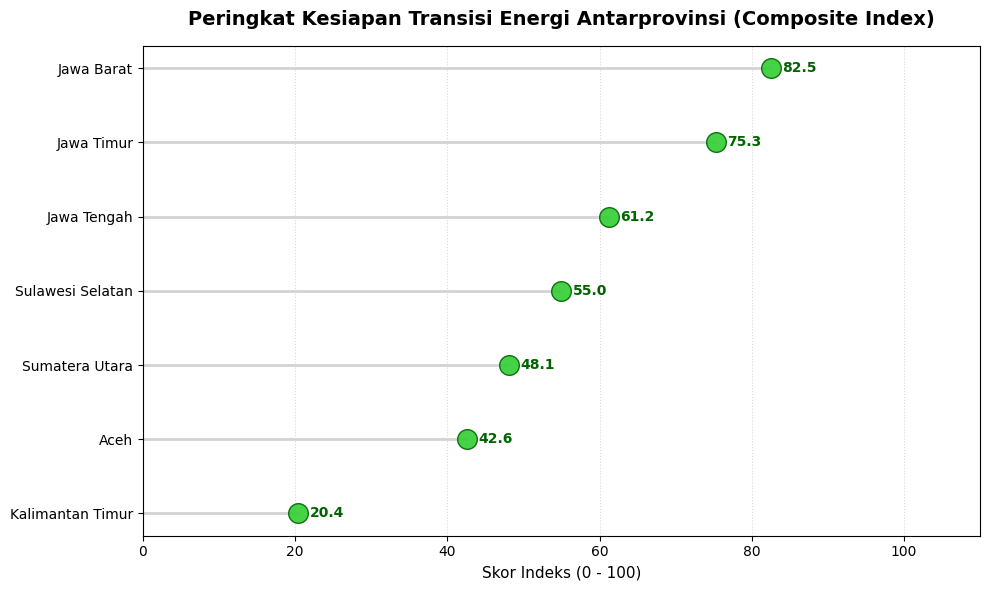

In [16]:
# Data hasil perangkingan indeks komposit daerah
df_prov_ranked = pd.DataFrame({
    'Provinsi': ['Jawa Barat', 'Jawa Timur', 'Jawa Tengah', 'Sulawesi Selatan', 'Sumatera Utara', 'Aceh', 'Kalimantan Timur'],
    'Energy_Transition_Index': [82.5, 75.3, 61.2, 55.0, 48.1, 42.6, 20.4]
}).sort_values(by='Energy_Transition_Index', ascending=True) # Diurutkan agar yang tertinggi di atas

plt.figure(figsize=(10, 6))

# Gambar tangkai lolipop
plt.hlines(y=df_prov_ranked['Provinsi'], xmin=0, xmax=df_prov_ranked['Energy_Transition_Index'], color='lightgrey', linewidth=2)

# Gambar bulatan lolipop dengan warna gradasi/menonjol (misal hijau untuk transisi energi)
plt.scatter(df_prov_ranked['Energy_Transition_Index'], df_prov_ranked['Provinsi'], color='limegreen', s=200, edgecolors='darkgreen', alpha=0.9, zorder=3)

# Tambahkan nilai indeks tepat di ujung bulatan
for i, row in df_prov_ranked.iterrows():
    plt.text(row['Energy_Transition_Index'] + 1.5, row['Provinsi'], f"{row['Energy_Transition_Index']:.1f}", va='center', fontweight='bold', color='darkgreen')

plt.title('Peringkat Kesiapan Transisi Energi Antarprovinsi (Composite Index)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Skor Indeks (0 - 100)', fontsize=11)
plt.xlim(0, 110) # Beri ruang untuk teks skor di kanan
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()